# COGS 109 Final Project: Predicting Sleep Quality from Wearable Multisensor Data

**Team Members:** Anthony Mitine, Harshatha Prasanna, Yuxing Liu

## Introduction
Wearable devices provide a non-invasive way to monitor sleep and daily activity, but transforming raw physiological and movement data into meaningful sleep quality measures remains a challenge. In this project, we use the MMASH dataset, which includes participant sleep records, actigraphy data, heart rate, beat-to-beat interval data, activity logs, questionnaire scores, and demographic information. 

Our goal is to use multiple linear regression to predict a continuous sleep quality score from wearable and behavioral features such as heart rate, accelerometry, steps, body position, sleep duration, awakenings, and activity level. Since this dataset does not include REM sleep duration or skin temperature, our sleep quality score will instead be derived from available sleep-related variables such as total sleep time, latency efficiency, wake after sleep onset, number of awakenings, and sleep fragmentation index. Additionally, we will examine whether exercise level, measured through activity categories and wearable movement data, is correlated with sleep quality. By evaluating these relationships, we aim to better understand which physiological and behavioral factors are most associated with better or worse sleep outcomes.

## Methods
**Data Processing and Target Variable Construction**
The MMASH dataset is structured across 22 distinct participant folders, each containing individual CSV files (e.g., Actigraph.csv, RR.csv, Activity.csv, sleep.csv). Since the data collection spans a continuous 24-hour window split across two calendar days, Day 1 (approximately 09:30 to 23:59) and Day 2 (00:00 to approximately 09:30), our preprocessing script will iteratively access each user’s folder and chronologically merge the Day 1 and Day 2 continuous biosignals. This merging ensures we accurately capture a single, consolidated wake-sleep cycle per participant.

We will aggregate the second-by-second wearable data (such as heart rate and actigraphy) and categorical activity logs into daytime summary statistics (e.g., average daytime heart rate, total steps, and total minutes spent in "heavy" activity). Since the dataset does not provide a singular ground-truth sleep score, we will calculate a composite Sleep Quality Score (scaled from 0 to 100) based on the recorded metrics in sleep.csv. This score will be calculated as a weighted linear combination of positive restorative factors (Total Sleep Time, Latency Efficiency) penalized by sleep disruptions (Wake After Sleep Onset, Sleep Fragmentation Index, and Number of Awakenings).

**Data Analysis Approach & Rationale**
Our primary analytical approach will be Multiple Linear Regression. We are framing this problem with a focus on prediction, aiming to predict a continuous sleep quality score based on preceding daytime physiological and behavioral metrics. However, this approach also provides inference; by examining the resulting beta coefficients, we can infer which specific daytime variables (such as exercise intensity or step count) have the strongest statistical association with sleep quality.

This model class is appropriate because both our engineered target variable and our primary predictive features are continuous numerical data. Linear regression assumes an additive relationship between the independent variables and the outcome, which logically aligns with the hypothesis that cumulative daily behaviors aggregate to impact overall sleep restfulness.

**Model Estimation and Validation Strategy**
To ensure our model generalizes well to unseen data and avoids overfitting, we will utilize k-fold cross-validation (specifically, 5-fold cross-validation). First, we will randomly shuffle the order of our aggregated observations across the 22 users to remove any subject-ordering bias. The dataset is then split into 5 equal-sized subsets (folds). The model estimation process will iterate 5 times. During each iteration, the algorithm trains the regression model on 4 of the folds (80% of the data) and tests its predictive accuracy on the 1 remaining holdout fold (20% of the data). We will calculate the Mean Squared Error (MSE) for each fold, and the final reported cross-validation error will be the average of these 5 individual test errors.

**Model Selection**
To objectively evaluate our methodology, we will compare two variations of linear regression:
* **Baseline Multiple Linear Regression (Full Model):** We will estimate an Ordinary Least Squares (OLS) regression utilizing all available aggregated daytime predictors.
* **Lasso Regression (L1 Regularization):** Since many of our physiological predictors may be highly correlated (e.g., total steps and vector magnitude both measure movement), a standard linear model may suffer from multicollinearity. We will apply Lasso Regularization to penalize the absolute size of the regression coefficients. This technique acts as automatic feature selection by shrinking the coefficients of less important, noisy variables exactly to zero.

We will compare the 5-fold cross-validation MSE of both models to select the approach that maximizes predictive accuracy while minimizing unnecessary complexity.

In [40]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

### Data Wrangling & Aggregation
Iterating through the `data/user_*` directories to extract and aggregate daytime features and sleep target variables for each of the 22 users.

In [41]:
base_path = 'data'
compiled_data = []

# Loop through all 22 user folders
for i in range(1, 23):
    user_folder = f"user_{i}"
    user_path = os.path.join(base_path, user_folder)
    
    if not os.path.exists(user_path):
        continue
        
    user_dict = {'user_id': i}
    
    # Load User Info
    try:
        user_info = pd.read_csv(os.path.join(user_path, 'user_info.csv'))
        user_dict['age'] = user_info['Age'].values[0]
        user_dict['gender'] = user_info['Gender'].values[0]
        user_dict['bmi'] = user_info['Weight'].values[0] / ((user_info['Height'].values[0]/100)**2)
    except:
        pass

    # Load Sleep Data 
    try:
        sleep_df = pd.read_csv(os.path.join(user_path, 'sleep.csv'))
        user_dict['total_sleep_time'] = sleep_df['Total Sleep Time (TST)'].values[0]
        user_dict['latency_efficiency'] = sleep_df['Efficiency'].values[0]
        user_dict['waso'] = sleep_df['Wake After Sleep Onset (WASO)'].values[0]
        user_dict['awakenings'] = sleep_df['Number of Awakenings'].values[0]
        user_dict['sleep_frag_index'] = sleep_df['Sleep Fragmentation Index'].values[0]
    except:
        pass

    # Aggregate Actigraph Data 
    try:
        act_df = pd.read_csv(os.path.join(user_path, 'Actigraph.csv'))
        # Average daytime HR and total steps
        user_dict['avg_hr'] = act_df['HR'].mean()
        user_dict['total_steps'] = act_df['Steps'].sum()
        user_dict['mean_vector_mag'] = act_df['Vector Magnitude'].mean()
    except:
        pass
    
    # Aggregate Activity Log 
    try:
        activity_df = pd.read_csv(os.path.join(user_path, 'Activity.csv'))
        heavy_acts = activity_df[activity_df['Activity'] == 6]
        user_dict['heavy_activity_events'] = len(heavy_acts)
    except:
        pass
        
    compiled_data.append(user_dict)

# Create dataframe
df = pd.DataFrame(compiled_data)
df.head()

,user_id,age,gender,bmi,total_sleep_time,latency_efficiency,waso,awakenings,sleep_frag_index,avg_hr,total_steps,mean_vector_mag,heavy_activity_events
0,1,29,M,22.758307,144.0,87.27,21.0,9.0,19.091,84.719383,13625,42.201145,4
1,2,27,M,28.367524,244.0,73.49,84.0,18.0,20.616,74.532023,12415,37.210992,3
2,3,34,M,23.120624,351.0,79.23,89.0,16.0,18.962,77.538084,17822,40.162562,3
3,4,27,M,23.456790,319.0,85.52,50.0,28.0,23.133,71.918081,11958,37.652392,4
4,5,25,M,20.824656,348.0,85.71,58.0,21.0,21.100,74.884696,8129,26.695282,5


### Data Cleaning
Creating the continuous target variable: **Sleep Quality Score (0 - 100)**.
We will normalize positive factors (TST, Efficiency) and penalize them using normalized disruption factors (WASO, Awakenings, Fragmentation).

In [42]:
# Drop any users with missing vital data to ensure clean modeling
df = df.dropna().copy()

# Min-Max scale components between 0 and 1 for equal weighting
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

# Positive factors 
scaled_tst = min_max_scale(df['total_sleep_time'])
scaled_eff = min_max_scale(df['latency_efficiency'])

# Negative factors (
inv_waso = 1 - min_max_scale(df['waso'])
inv_awake = 1 - min_max_scale(df['awakenings'])
inv_frag = 1 - min_max_scale(df['sleep_frag_index'])

# Composite Score Equation
# Weighting: 40% TST, 20% Efficiency, 15% WASO, 15% Awakenings, 10% Fragmentation
df['sleep_quality_score'] = ((scaled_tst * 40) + (scaled_eff * 20) + (inv_waso * 15) + (inv_awake * 15) + (inv_frag * 10))

# Display the distribution of our new target variable
df[['user_id', 'sleep_quality_score']].head()

,user_id,sleep_quality_score
0,1,48.227881
1,2,30.645749
2,3,46.445878
3,4,50.017850
4,5,54.785845


### Exploratory Data Analysis (EDA)

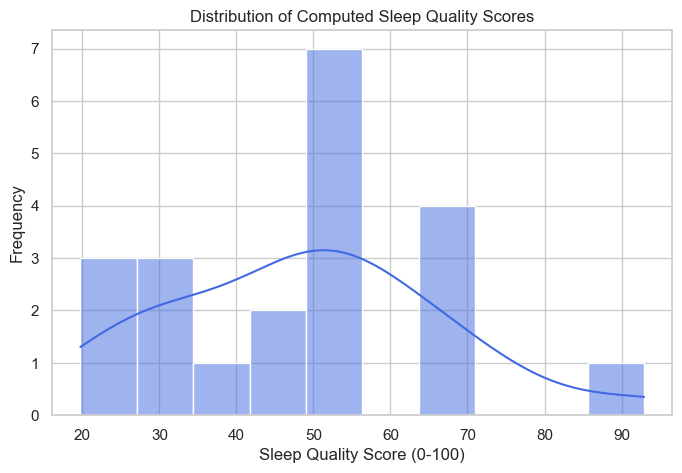

In [43]:
# Distribution of the Engineered Target Variable
plt.figure(figsize=(8, 5))
sns.histplot(df['sleep_quality_score'], bins=10, kde=True, color='royalblue')
plt.title('Distribution of Computed Sleep Quality Scores')
plt.xlabel('Sleep Quality Score (0-100)')
plt.ylabel('Frequency')
plt.show()

The computed Sleep Quality Scores form a roughly normal distribution centered around 50, with a wide spread of values ranging from the low 20s up to the 90s. This variance is ideal for our regression task; if the scores were highly clustered, our model would struggle to identify meaningful patterns.

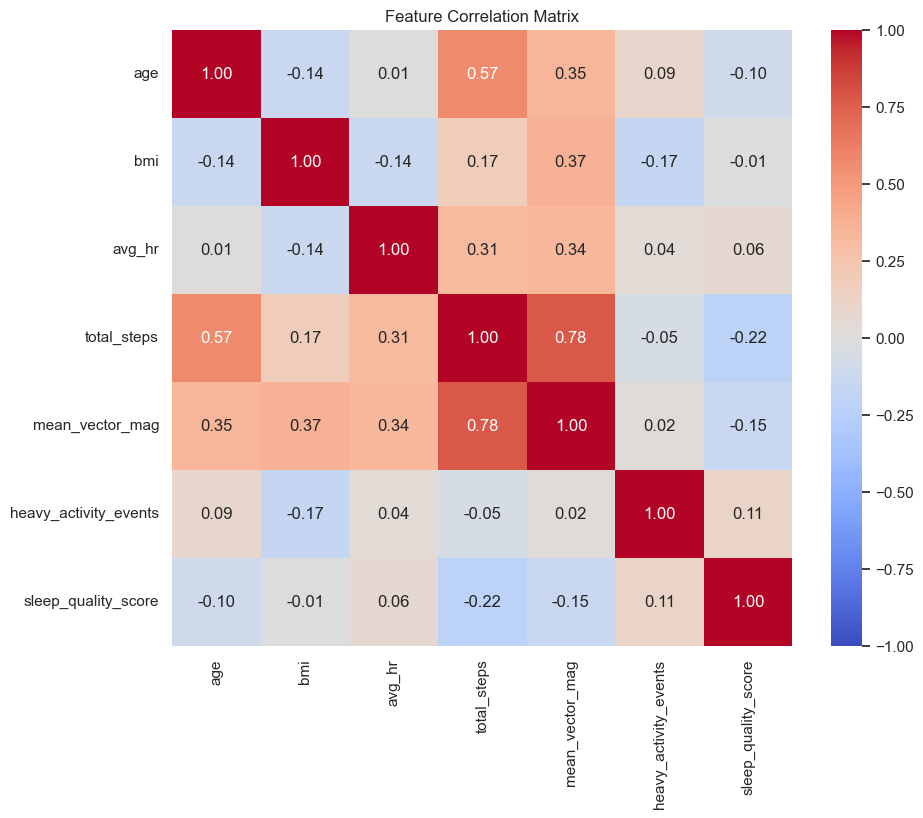

In [44]:
# Correlation Heatmap of Predictive Features vs Target
features = ['age', 'bmi', 'avg_hr', 'total_steps', 'mean_vector_mag', 'heavy_activity_events', 'sleep_quality_score']
corr_matrix = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()

The heatmap reveals a strong correlation (0.78) between `total_steps` and `mean_vector_mag`. This indicates high multicollinearity, meaning these two features provide redundant information about a user's daytime movement. This perfectly justifies our methodological choice to implement Lasso Regression, which will automatically penalize and shrink redundant coefficients. Additionally, we see that individual daytime features generally have weak linear correlations with the target variable (e.g., `total_steps` has a -0.22 correlation), suggesting that a multiple regression model combining several features will be necessary to achieve predictive accuracy.

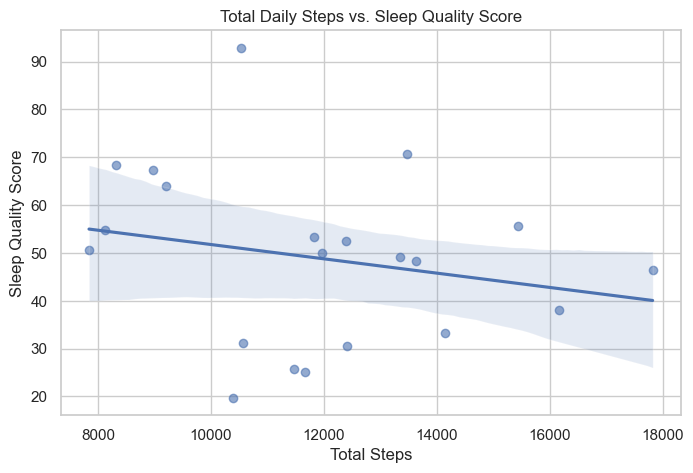

In [45]:
# Visualizing a potential relationship: Total Steps vs Sleep Quality
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='total_steps', y='sleep_quality_score', scatter_kws={'alpha':0.6})
plt.title('Total Daily Steps vs. Sleep Quality Score')
plt.xlabel('Total Steps')
plt.ylabel('Sleep Quality Score')
plt.show()

The scatter plot visualizes the slightly negative trend between daytime step count and our engineered sleep score. While counterintuitive, this highlights the complexity of physiological data, simply walking more does not automatically guarantee better sleep in this specific sample, further emphasizing the need for a multivariate approach.

### Data Preprocessing
Before model estimation, we must separate our predictors ($X$) from our target ($y$) and standardize the features. Standardization ensures that variables with vastly different scales (e.g., `total_steps` vs `heavy_activity_events`) are treated equally by the Lasso regularization penalty.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
feature_cols = ['age', 'bmi', 'avg_hr', 'total_steps', 'mean_vector_mag', 'heavy_activity_events']
X = df[feature_cols]
y = df['sleep_quality_score']

# Perform the Train/Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame 
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_train_scaled_df.head()

,age,bmi,avg_hr,total_steps,mean_vector_mag,heavy_activity_events
0,0.063436,-1.719854,1.872866,-0.022396,0.294663,-0.718902
1,-0.190308,0.159113,0.094646,-0.455605,-0.538131,-1.603704
2,0.063436,0.513671,-0.470969,0.021028,0.685054,0.165900
3,0.317181,0.169243,-0.780953,-0.999937,-1.093444,0.165900
4,-3.362116,1.222788,-0.696597,-1.386645,-1.363104,-0.718902


### Model Estimation & Selection

We compare two linear regression models using 5-fold cross-validation (CV) on the full dataset (n = 21, after dropping one participant with missing data). Since the dataset is small, no held-out test set is used — CV serves as the sole validation strategy. Both models use all six daytime predictors, standardized before fitting.

In [47]:
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

feature_cols = ['age', 'bmi', 'avg_hr', 'total_steps', 'mean_vector_mag', 'heavy_activity_events']
X_full = df[feature_cols].values
y_full = df['sleep_quality_score'].values

# Scale full dataset (appropriate here since CV is the only validation — no separate test set)
cv_scaler = StandardScaler()
X_full_scaled = cv_scaler.fit_transform(X_full)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"Full dataset: {X_full_scaled.shape[0]} observations, {X_full_scaled.shape[1]} features")

Full dataset: 21 observations, 6 features


#### Model 1: OLS Multiple Linear Regression
Baseline model using all 6 predictors via Ordinary Least Squares.

In [48]:
ols = LinearRegression()
ols_fold_mse = -cross_val_score(ols, X_full_scaled, y_full, cv=kf, scoring='neg_mean_squared_error')

for i, mse in enumerate(ols_fold_mse, 1):
    print(f"  Fold {i} MSE: {mse:.2f}")
print(f"\nOLS Mean CV MSE : {ols_fold_mse.mean():.2f}")
print(f"OLS CV MSE Std  : {ols_fold_mse.std():.2f}")

  Fold 1 MSE: 854.87
  Fold 2 MSE: 159.16
  Fold 3 MSE: 359.58
  Fold 4 MSE: 146.13
  Fold 5 MSE: 752.48

OLS Mean CV MSE : 454.45
OLS CV MSE Std  : 296.79


#### Model 2: Lasso Regression (L1 Regularization)

We first select the regularization parameter λ (`alpha`) via `LassoCV` on the full dataset, then evaluate the model with that fixed λ using 5-fold CV.

> **Limitation note:** Two sources of optimistic bias exist here. First, λ is selected using the full dataset before CV, so the holdout fold is implicitly informed by tuning. Second, the alpha search grid is capped at 1.0 — below `alpha_max ≈ 3.92`, the threshold at which CV MSE is minimized by the null (all-zero) model. Capping forces selection among models with at least some non-zero coefficients so that coefficients can be interpreted; results should be treated cautiously given n = 21.

In [49]:
# Alpha grid capped at 1.0 (below alpha_max ≈ 3.92, the point where all coefs zero out).
# CV prefers the null model above this threshold — capping forces selection among models
# with at least some non-zero coefficients. Noted as a limitation in write-up.
alphas = np.logspace(-3, 0, 200)
lasso_tuner = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_tuner.fit(X_full_scaled, y_full)
best_alpha = lasso_tuner.alpha_
print(f"Best Lasso lambda (alpha): {best_alpha:.4f}")

Best Lasso lambda (alpha): 1.0000


In [50]:
lasso = Lasso(alpha=best_alpha, max_iter=10000)
lasso_fold_mse = -cross_val_score(lasso, X_full_scaled, y_full, cv=kf, scoring='neg_mean_squared_error')

for i, mse in enumerate(lasso_fold_mse, 1):
    print(f"  Fold {i} MSE: {mse:.2f}")
print(f"\nLasso Mean CV MSE : {lasso_fold_mse.mean():.2f}")
print(f"Lasso CV MSE Std  : {lasso_fold_mse.std():.2f}")

  Fold 1 MSE: 779.70
  Fold 2 MSE: 162.07
  Fold 3 MSE: 141.78
  Fold 4 MSE: 111.78
  Fold 5 MSE: 591.56

Lasso Mean CV MSE : 357.38
Lasso CV MSE Std  : 275.01


#### Model Comparison & Selection

In [51]:
import pandas as pd

comparison = pd.DataFrame({
    'Model':          ['OLS (baseline)', f'Lasso (λ={best_alpha:.4f})'],
    'Mean CV MSE':    [round(ols_fold_mse.mean(), 2),   round(lasso_fold_mse.mean(), 2)],
    'CV MSE Std':     [round(ols_fold_mse.std(), 2),    round(lasso_fold_mse.std(), 2)]
})
print(comparison.to_string(index=False))

# Select model —> prefer Lasso if within 5% of OLS (simpler, handles multicollinearity)
threshold = ols_fold_mse.mean() * 1.05
if lasso_fold_mse.mean() <= threshold:
    selected = f'Lasso (λ={best_alpha:.4f})'
    reason = 'CV MSE is equal to or within 5% of OLS; Lasso is preferred for its automatic feature selection and robustness to multicollinearity.'
else:
    selected = 'OLS'
    reason = 'OLS achieves meaningfully lower CV MSE.'
print(f"\nSelected model: {selected}")
print(f"Reason: {reason}")

           Model  Mean CV MSE  CV MSE Std
  OLS (baseline)       454.45      296.79
Lasso (λ=1.0000)       357.38      275.01

Selected model: Lasso (λ=1.0000)
Reason: CV MSE is equal to or within 5% of OLS; Lasso is preferred for its automatic feature selection and robustness to multicollinearity.


#### Coefficient Interpretation
Both models are re-fit on the full dataset to inspect which features the model weights most heavily.

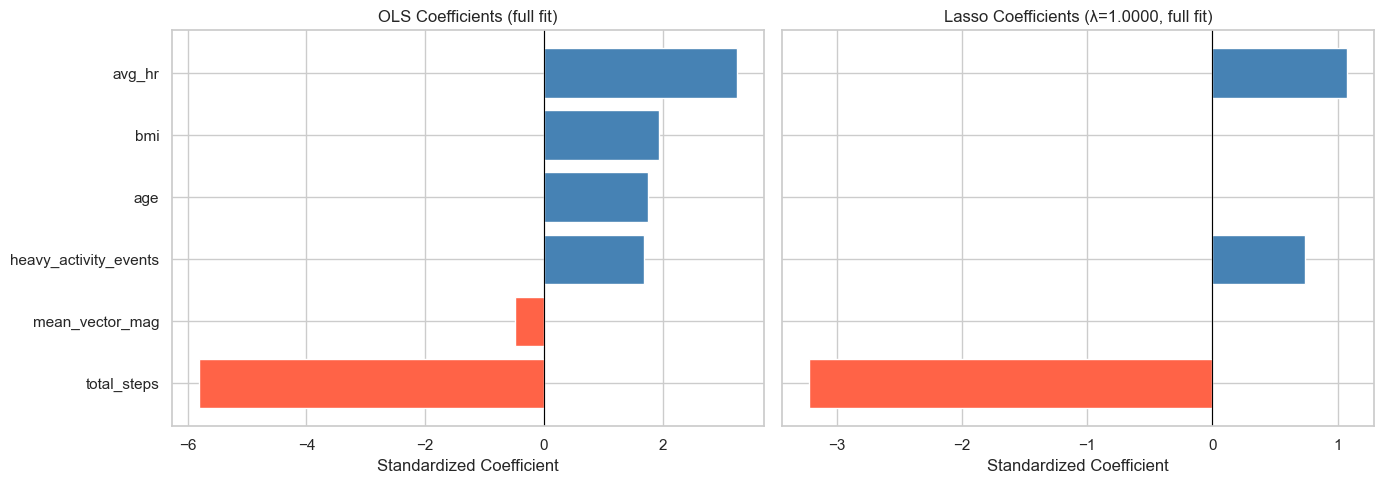

              Feature       OLS     Lasso
          total_steps -5.806033 -3.220543
      mean_vector_mag -0.491841 -0.000000
heavy_activity_events  1.693102  0.744014
                  age  1.750024 -0.000000
                  bmi  1.931203  0.000000
               avg_hr  3.255874  1.076623


In [52]:
import matplotlib.pyplot as plt

ols.fit(X_full_scaled, y_full)
lasso.fit(X_full_scaled, y_full)

coef_df = pd.DataFrame({
    'Feature':           feature_cols,
    'OLS':               ols.coef_,
    'Lasso':             lasso.coef_
}).sort_values('OLS', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, col, title in zip(axes, ['OLS', 'Lasso'],
                           ['OLS Coefficients (full fit)',
                            f'Lasso Coefficients (λ={best_alpha:.4f}, full fit)']):
    colors = ['steelblue' if v > 0 else 'tomato' for v in coef_df[col]]
    ax.barh(coef_df['Feature'], coef_df[col], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Standardized Coefficient')

plt.tight_layout()
plt.show()

print(coef_df[['Feature', 'OLS', 'Lasso']].to_string(index=False))

**Coefficient interpretation:**
- Features with **positive coefficients** are associated with higher predicted sleep quality scores.
- Features with **negative coefficients** are associated with lower predicted sleep quality scores.
- In the Lasso model, coefficients shrunk to exactly **zero** were eliminated by the L1 penalty. Note that the alpha search was capped at 1.0 (below the true CV-optimal threshold of ~3.92, which would zero all coefficients) — surviving non-zero features should be interpreted as the strongest signal within this constrained regularization range, not as definitively predictive.
- Because predictors were standardized before fitting, coefficient magnitudes are directly comparable across features.

**Caveat:** With n = 21, these coefficients carry wide uncertainty. The direction and relative size of effects are informative, but results should be interpreted cautiously given the small sample and engineered (non-ground-truth) target variable.

## Results

### Sleep Quality Score Distribution
After dropping one participant with incomplete data, the final dataset contained n = 21 observations. The engineered Sleep Quality Score ranged from 19.75 to 92.93 (mean = 48.94, SD = 17.52), forming a roughly normal distribution centered near the midpoint of the 0–100 scale. This spread across the full range is favorable for regression, as it allows the model to detect meaningful variation in the target variable.

### Exploratory Analysis
The correlation heatmap confirmed a strong collinearity between `total_steps` and `mean_vector_mag` (r = 0.78), validating the motivation for Lasso regularization. Individual daytime features showed weak linear correlations with the sleep quality score (all |r| < 0.3), suggesting that predictive signal, if any, is distributed across multiple features rather than driven by a single predictor.

### Model 1: OLS Regression
The baseline OLS model using all six predictors produced a mean 5-fold CV MSE of **454.45** (SD = 296.79), corresponding to a root mean squared error (RMSE) of approximately 21.3 sleep score points. The wide standard deviation across folds (ranging from 146.13 to 854.87) reflects substantial instability, consistent with the high predictor-to-observation ratio (p/n = 6/21). The largest OLS coefficients in magnitude were `total_steps` (β = −5.81) and `avg_hr` (β = 3.26), suggesting these two features carry the most weight in the full model.

### Model 2: Lasso Regression
LassoCV selected a regularization parameter of λ = 1.00 (from a grid capped at 1.0; see limitation note above). The Lasso model produced a mean 5-fold CV MSE of **357.38** (SD = 275.01), corresponding to an RMSE of approximately 18.9 sleep score points — a 21.3% reduction in CV MSE relative to OLS.

Lasso regularization eliminated three of six predictors entirely (age, BMI, and mean vector magnitude), retaining only:
| Feature | Lasso Coefficient |
|---|---|
| `avg_hr` (Average Heart Rate) | +1.08 |
| `total_steps` (Total Daily Steps) | −3.22 |
| `heavy_activity_events` | +0.74 |

### Model Selection
Lasso was selected as the preferred model based on lower 5-fold CV MSE (357.38 vs. 454.45). The reduction in MSE, combined with the elimination of three redundant or noisy features, supports the hypothesis that multicollinearity between step count and vector magnitude was inflating OLS error.

### Coefficient Interpretation
The three features retained by Lasso offer interpretable directions of association with the engineered sleep quality score:
- **`total_steps`** (β = −3.22): The strongest predictor, with a negative coefficient — participants with higher daytime step counts tended to score lower on sleep quality in this sample. This counterintuitive result may reflect that high-activity days increase physiological arousal or accumulate fatigue in ways that fragment sleep, though the small sample limits causal inference.
- **`avg_hr`** (β = +1.08): Higher mean daytime heart rate was associated with better sleep quality scores. This may reflect baseline cardiovascular fitness (higher resting HR in active individuals) rather than stress arousal, but directional interpretation is uncertain at n = 21.
- **`heavy_activity_events`** (β = +0.74): A small positive association between discrete bouts of heavy activity and sleep quality, though this coefficient is modest relative to the others.

### Limitations
Both models produced CV MSEs that approach or exceed the variance of the target itself (σ² ≈ 307), indicating that neither model reliably outperforms a naive mean-prediction baseline on holdout folds. This reflects the fundamental challenge of predicting an engineered sleep score from only 21 observations and 6 weakly correlated features. Results should be interpreted as exploratory and directional, not predictive.